In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

DATA = Path("data/raw") if Path("data/raw").exists() else Path("raw")

def parse_cids(raw: str) -> list[int]:
    raw = raw.strip("[]")
    if not raw:
        return []
    return [int(x) for x in raw.split()]

def token_count(text: str) -> int:
    return len(str(text).split())


## Load

In [2]:
corpus = pd.read_csv(DATA / "updated_corpus.csv")
train = pd.read_csv(DATA / "Train" / "train.csv")

print("updated_corpus:", corpus.shape)
print("train:", train.shape)

display(corpus.head())
display(train.head())


updated_corpus: (262168, 2)
train: (119456, 4)


,text,cid
0,"Thông tư này hướng dẫn tuần tra, canh gác bảo ...",0
1,"1. Hàng năm trước mùa mưa, lũ, Ủy ban nhân dân...",1
2,Tiêu chuẩn của các thành viên thuộc lực lượng ...,2
3,"Nhiệm vụ của lực lượng tuần tra, canh gác đê\n...",3
4,"Phù hiệu của lực lượng tuần tra, canh gác đê\n...",4


,question,context,cid,qid
0,Người học ngành quản lý khai thác công trình t...,"['Khả năng học tập, nâng cao trình độ\n- Khối ...",[62492],161615
1,Nội dung lồng ghép vấn đề bình đẳng giới trong...,['Nội dung lồng ghép vấn đề bình đẳng giới tro...,[151154],80037
2,Sản phẩm phần mềm có được hưởng ưu đãi về thời...,"['""Điều 20. Ưu đãi về thời gian miễn thuế, giả...",[75071],124074
3,Điều kiện để giáo viên trong cơ sở giáo dục mầ...,"['Điều kiện được hưởng\nCán bộ quản lý, giáo v...",[225897],146841
4,Nguyên tắc áp dụng phụ cấp ưu đãi nghề y tế th...,"['Nguyên tắc áp dụng\n1. Trường hợp công chức,...",[68365],6176


## Null & Dups

In [3]:
corpus_nulls = corpus[corpus[["cid", "text"]].isna().any(axis=1)]
corpus_dups = corpus[corpus.duplicated(subset=["cid"], keep=False)].sort_values("cid")

print(f"updated_corpus null rows: {len(corpus_nulls)}")
display(corpus_nulls if not corpus_nulls.empty else pd.DataFrame())
print(f"updated_corpus duplicate cid rows: {len(corpus_dups)}")
display(corpus_dups if not corpus_dups.empty else pd.DataFrame())


updated_corpus null rows: 0


""


updated_corpus duplicate cid rows: 465


,text,cid
261915,"['Vị trí, chức năng, nhiệm vụ và quyền hạn\n1....",19478
261756,"['Vị trí, chức năng, nhiệm vụ và quyền hạn\n1....",19478
261926,['Nhiệm vụ và quyền hạn của Hội đồng quản lý\n...,19478
262151,"['""Điều 4. Các trường hợp cấp, cấp lại chứng c...",21915
261729,"['""8. Bác sĩ y học cổ truyền, y sĩ y học cổ tr...",21915
...,...,...
261683,"['""2.\xa0Quy trình thành lập trường đại học gồ...",173080
262037,['Người phát ngôn và cung cấp thông tin cho bá...,178774
262002,['Người phát ngôn và cung cấp thông tin cho bá...,178774
261987,['Chuyển nhượng có thời hạn quyền khai thác tà...,254488


In [4]:
train_nulls = train[train[["question", "context", "cid"]].isna().any(axis=1)]
train_dups = train[train.duplicated(subset=["question"], keep=False)].sort_values("question")

print(f"train null rows: {len(train_nulls)}")
display(train_nulls if not train_nulls.empty else pd.DataFrame())
print(f"train duplicate question rows: {len(train_dups)}")
display(train_dups if not train_dups.empty else pd.DataFrame())

train null rows: 0


""


train duplicate question rows: 3988


,question,context,cid,qid
3898,Ai có quyền ban bố tình trạng khẩn cấp về dịch...,['Nguyên tắc và thẩm quyền ban bố tình trạng k...,[109972],43305
64623,Ai có quyền ban bố tình trạng khẩn cấp về dịch...,['Nguyên tắc và thẩm quyền ban bố tình trạng k...,[109972],96313
40645,Ai có quyền bổ nhiệm Giám đốc Đại học quốc gia...,"['Giám đốc, Phó Giám đốc Đại học quốc gia\n......",[144628],74209
51600,Ai có quyền bổ nhiệm Giám đốc Đại học quốc gia...,"['Giám đốc, Phó Giám đốc Đại học quốc gia\n......",[144628],166134
94683,Ai có quyền công nhận công chức thanh tra chuy...,"['Thẩm quyền, trình tự, thủ tục công nhận, thô...",[104549],105637
...,...,...,...,...
87023,Ủy ban quốc phòng và an ninh có nhiệm vụ và qu...,"['Nhiệm vụ, quyền hạn của Ủy ban quốc phòng và...",[49682],5050
89521,Ủy ban quốc phòng và an ninh có nhiệm vụ và qu...,"['Nhiệm vụ, quyền hạn của Ủy ban quốc phòng và...",[49682],75290
6483,Ủy quyền là gì?,"['""Điều 138. Đại diện theo ủy quyền\n1. Cá nhâ...",[58264 58688],110204
43464,Ủy quyền là gì?,"['""Điều 138. Đại diện theo ủy quyền\n1. Cá nhâ...",[58264 58688],7737


## Train Q-A data

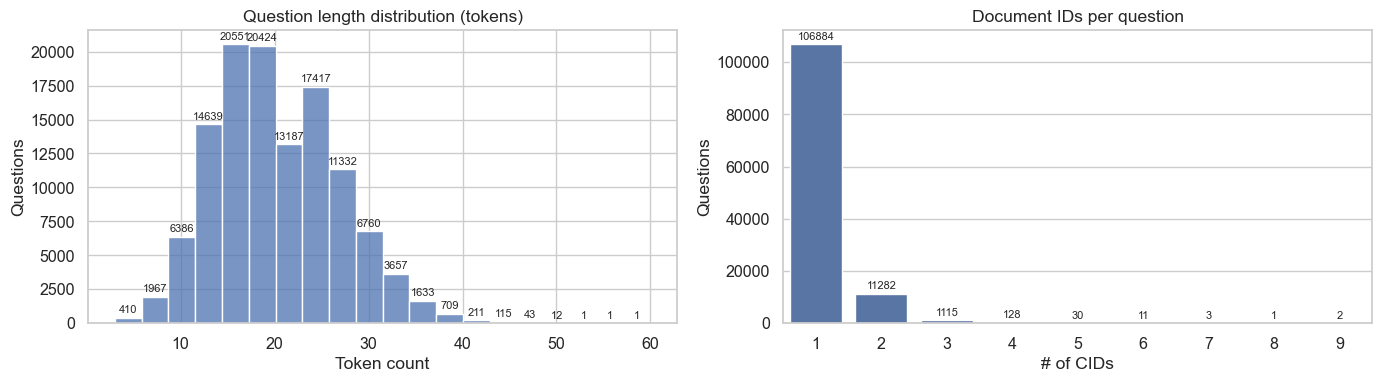

In [5]:
train = train.copy()
corpus = corpus.copy()
train["question_tokens"] = train["question"].map(token_count)
train["cid_count"] = train["cid"].map(lambda raw: len(parse_cids(raw)))
corpus["doc_tokens"] = corpus["text"].map(token_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train["question_tokens"], bins=20, ax=axes[0])
axes[0].set(title="Question length distribution (tokens)", xlabel="Token count", ylabel="Questions")
for bar in axes[0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0].annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height),
                         ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")

cid_counts = train["cid_count"].value_counts().sort_index()
sns.barplot(x=cid_counts.index, y=cid_counts.values, ax=axes[1])
axes[1].set(title="Document IDs per question", xlabel="# of CIDs", ylabel="Questions")
for bar in axes[1].patches:
    height = bar.get_height()
    if height > 0:
        axes[1].annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height),
                         ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")

plt.tight_layout()
plt.show()


## Corpus Length

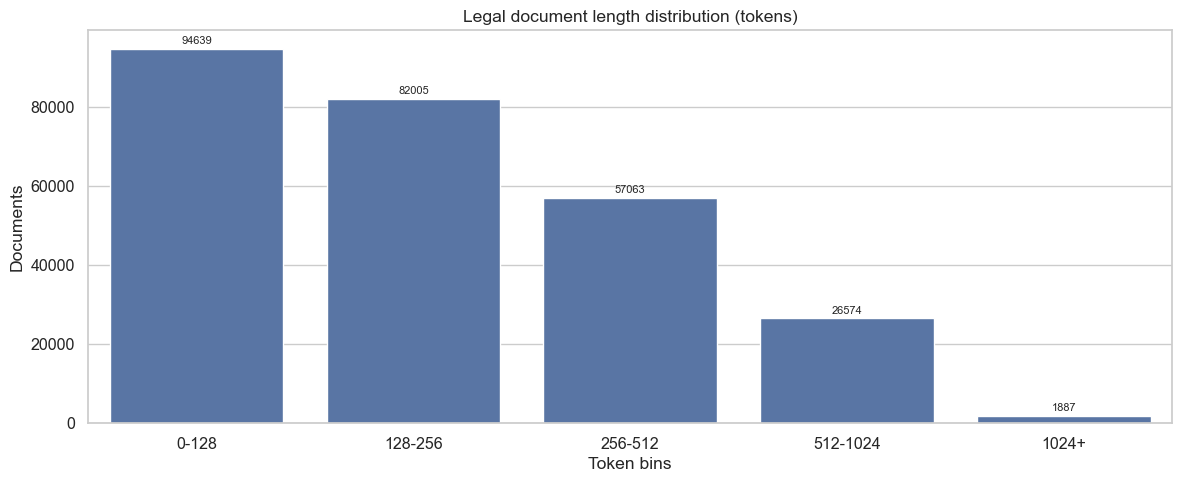

In [6]:
# Distribution

bins = [0, 128, 256, 512, 1024, float("inf")]
labels = ["0-128", "128-256", "256-512", "512-1024", "1024+"]
corpus["doc_bin"] = pd.cut(corpus["doc_tokens"], bins=bins, labels=labels, right=False)

ax = sns.countplot(data=corpus, x="doc_bin", order=labels)
ax.set(title="Legal document length distribution (tokens)", xlabel="Token bins", ylabel="Documents")
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height),
                    ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")
plt.tight_layout()
plt.show()


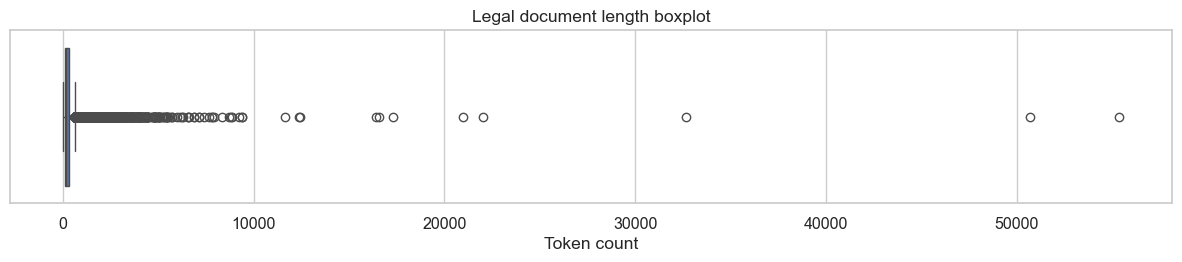

In [7]:
# Boxplot

fig, ax = plt.subplots(figsize=(12, 2.8))
sns.boxplot(x=corpus["doc_tokens"], ax=ax)
ax.set_title("Legal document length boxplot")
ax.set_xlabel("Token count")
plt.tight_layout()
plt.show()


In [8]:
stats = corpus["doc_tokens"].describe()
q1 = stats["25%"]
q3 = stats["75%"]
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = corpus[(corpus["doc_tokens"] < lower) | (corpus["doc_tokens"] > upper)]
short_counts = {k: int((corpus["doc_tokens"] <= k).sum()) for k in [1, 2, 5, 10, 20, 50]}
long_counts = {k: int((corpus["doc_tokens"] > k).sum()) for k in [512, 1024, 2048, 5000]}

print("Corpus document length stats")
print(f"n: {int(stats['count']):,}")
print(f"min: {stats['min']:.0f}")
print(f"q1: {q1:.0f}")
print(f"median: {stats['50%']:.0f}")
print(f"q3: {q3:.0f}")
print(f"max: {stats['max']:.0f}")
print(f"mean: {stats['mean']:.1f}")
print(f"iqr: {iqr:.0f}")
print(f"outliers: {len(outliers):,}")
print("short-doc buckets")
for k, v in short_counts.items():
    print(f"<= {k} tokens: {v:,}")
print("long-doc buckets")
for k, v in long_counts.items():
    print(f"> {k} tokens: {v:,}")


Corpus document length stats
n: 262,168
min: 1
q1: 96
median: 175
q3: 307
max: 55368
mean: 240.3
iqr: 211
outliers: 13,458
short-doc buckets
<= 1 tokens: 3
<= 2 tokens: 9
<= 5 tokens: 79
<= 10 tokens: 412
<= 20 tokens: 1,579
<= 50 tokens: 16,339
long-doc buckets
> 512 tokens: 28,342
> 1024 tokens: 1,883
> 2048 tokens: 373
> 5000 tokens: 54


In [9]:
# Outlier samples

print("Top longest corpus outliers")
display(corpus.sort_values("doc_tokens", ascending=False)[["cid", "doc_tokens", "text"]].head(10))

print("Very short corpus docs (<= 5 tokens)")
display(corpus[corpus["doc_tokens"] <= 5].sort_values(["doc_tokens", "cid"])[["cid", "doc_tokens", "text"]].head(20))

print("Shortest corpus docs")
display(corpus.sort_values("doc_tokens", ascending=True)[["cid", "doc_tokens", "text"]].head(10))

print("Repeated corpus cid groups")
cid_dups = corpus[corpus.duplicated(subset=["cid"], keep=False)].sort_values(["cid", "text"])
display(cid_dups.groupby("cid").size().sort_values(ascending=False).head(20).reset_index(name="rows"))
display(cid_dups[["cid", "doc_tokens", "text"]].head(20))

print("Repeated train question groups")
question_dups = train[train.duplicated(subset=["question"], keep=False)].sort_values(["question", "qid"])
display(question_dups.groupby("question").size().sort_values(ascending=False).head(20).reset_index(name="rows"))
display(question_dups[["question", "cid", "qid"]].head(20))


Top longest corpus outliers


,cid,doc_tokens,text
15843,17161,55368,"1. Sửa đổi, bổ sung Điều 3 như sau:\na) Sửa đổ..."
25326,27908,50664,1. Tài khoản 111 - Tiền mặt\nTài khoản này dùn...
22674,24965,32667,"1. Sửa đổi, bổ sung điểm 1 như sau:\na) Sửa đổ..."
45312,50363,22006,"1. Bổ sung Khoản 6, Khoản 7 Điều 3 như sau:\n“..."
25319,27900,20966,1. Tài khoản 133 - Thuế GTGT được khấu trừ\nTà...
31831,35135,17285,"1. Sửa đổi, bổ sung Điều 3 như sau:\na) Sửa đổ..."
35274,38956,16582,"1. Sửa đổi, bổ sung Điều 2 như sau:\n“Điều 2. ..."
34331,37891,16410,"1. Bổ sung khoản 7, khoản 8, khoản 9 vào Điều ..."
38370,42461,12422,1. Bổ sung Điều 2a như sau:\n“Điều 2a. Giải th...
46627,51940,12372,"1. Người có quyền lợi, nghĩa vụ liên quan có c..."


Very short corpus docs (<= 5 tokens)


,cid,doc_tokens,text
59775,68818,1,....
261795,121586,1,['...']
262009,217956,1,['...']
105342,181817,2,...\n\n....
109288,194853,2,....\n...
115482,216011,2,...\n...
119292,229433,2,...\n...
126252,256577,2,...\n...
218580,578502,2,Đại diện.........................................
79099,108219,3,"1. Nhà, đất."


Shortest corpus docs


...

,cid,rows
0,64266,51
1,64816,28
2,62882,16
3,23302,15
4,66453,14
5,65784,13
6,87387,12
7,65776,12
8,102648,12
9,94166,11


,cid,doc_tokens,text
261926,19478,229,['Nhiệm vụ và quyền hạn của Hội đồng quản lý\n...
261756,19478,303,"['Vị trí, chức năng, nhiệm vụ và quyền hạn\n1...."
261915,19478,303,"['Vị trí, chức năng, nhiệm vụ và quyền hạn\n1...."
261729,21915,237,"['""8. Bác sĩ y học cổ truyền, y sĩ y học cổ tr..."
262151,21915,220,"['""Điều 4. Các trường hợp cấp, cấp lại chứng c..."
261699,22660,187,"['""Điều 24. Bầu thành viên Ban thanh tra nhân ..."
261839,22660,322,"['Bãi nhiệm, miễn nhiệm thành viên Ban thanh t..."
261758,23302,177,"['""Điều 2. Giải thích từ ngữ\nTrong luật này, ..."
261652,23302,310,"['""Điều 4. Tự công bố sản phẩm\n1. Tổ chức, cá..."
261814,23302,310,"['""Điều 4. Tự công bố sản phẩm\n1. Tổ chức, cá..."


Repeated train question groups


,question,rows
0,Quỹ bình ổn giá xăng dầu được thực hiện như th...,25
1,Thương nhân kinh doanh dịch vụ xăng dầu có quy...,14
2,Thông tư 04/2023/TT-BTP được áp dụng từ ngày mấy?,12
3,Thông tư 24/2023/TT-BCA về đăng ký xe được chí...,11
4,Ký kết thỏa thuận quốc tế là gì?,11
5,Nghị định 31/2023/NĐ-CP có hiệu lực từ ngày nào?,10
6,Viên chức là ai?,10
7,Hóa đơn điện tử là gì?,9
8,Ký kết thỏa thuận quốc tế dựa trên những nguyê...,9
9,Hợp đồng lao động là gì?,9


,question,cid,qid
3898,Ai có quyền ban bố tình trạng khẩn cấp về dịch...,[109972],43305
64623,Ai có quyền ban bố tình trạng khẩn cấp về dịch...,[109972],96313
40645,Ai có quyền bổ nhiệm Giám đốc Đại học quốc gia...,[144628],74209
51600,Ai có quyền bổ nhiệm Giám đốc Đại học quốc gia...,[144628],166134
107334,Ai có quyền công nhận công chức thanh tra chuy...,[104548],38456
94683,Ai có quyền công nhận công chức thanh tra chuy...,[104549],105637
115181,Ai có quyền cấp đổi Chứng minh quân nhân chuyê...,[50323],81782
42621,Ai có quyền cấp đổi Chứng minh quân nhân chuyê...,[50323],111117
116316,"Ai có quyền phê duyệt chương trình, kế hoạch h...",[82176],18513
72967,"Ai có quyền phê duyệt chương trình, kế hoạch h...",[82176],85754
